### Audio Similarity Using Pretrained Embeddings

In [3]:
import os
import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2Model
)

from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA

c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Pretrained Wav2Vec2

In [4]:
processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

model.eval()

print("Wav2Vec2 loaded successfully")

c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Tejeswar Srinivasan\.cache\huggingface\hub\models--facebook--wav2vec2-base-960h. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 210/210 [00:00<00:00, 6026.79it

Wav2Vec2 loaded successfully


### Load Audio Files

In [5]:
audio_files = [
    "audio/audio_1.wav",
    "audio/audio_2.wav",
    "audio/audio_3.wav",
    "audio/audio_4.wav",
    "audio/audio_5.wav"
]

audio_clips = []
labels = []

for file in audio_files:

    audio, sr = librosa.load(
        file,
        sr=16000,
        mono=True
    )

    audio_clips.append(audio)

    labels.append(
        os.path.basename(file)
    )

print(labels)

['audio_1.wav', 'audio_2.wav', 'audio_3.wav', 'audio_4.wav', 'audio_5.wav']


### Display Waveforms

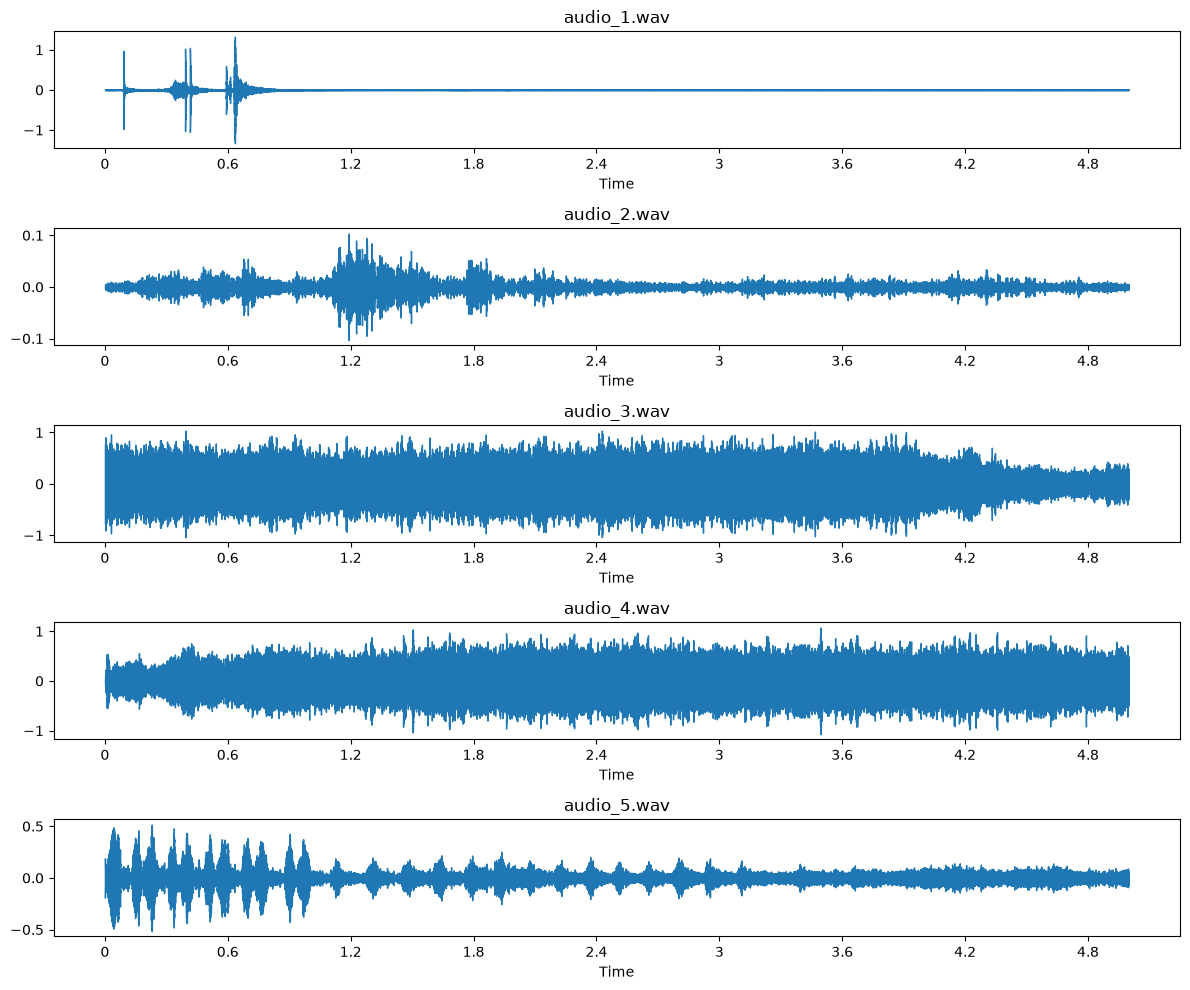

In [6]:
fig, axes = plt.subplots(
    len(audio_clips),
    1,
    figsize=(12,10)
)

for i, audio in enumerate(audio_clips):

    librosa.display.waveshow(
        audio,
        sr=16000,
        ax=axes[i]
    )

    axes[i].set_title(labels[i])

plt.tight_layout()
plt.show()

### Extract Wav2Vec2 Embeddings

In [7]:
embeddings = []

for audio in audio_clips:

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    with torch.no_grad():

        outputs = model(
            **inputs
        )

    embedding = (
        outputs.last_hidden_state
        .mean(dim=1)
        .squeeze()
        .numpy()
    )

    embeddings.append(
        embedding
    )

embeddings = np.array(
    embeddings
)

print(
    "Embedding shape:",
    embeddings.shape
)

Embedding shape: (5, 768)


### Similarity Matrix

In [8]:
similarity_matrix = cosine_similarity(
    embeddings
)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=labels,
    columns=labels
)

similarity_df

,audio_1.wav,audio_2.wav,audio_3.wav,audio_4.wav,audio_5.wav
audio_1.wav,1.000000,0.858759,0.810861,0.462321,0.553962
audio_2.wav,0.858759,1.000000,0.938459,0.660217,0.799343
audio_3.wav,0.810861,0.938459,1.000000,0.690224,0.779414
audio_4.wav,0.462321,0.660217,0.690224,1.000000,0.791613
audio_5.wav,0.553962,0.799343,0.779414,0.791613,1.000000


### Similarity Heatmap

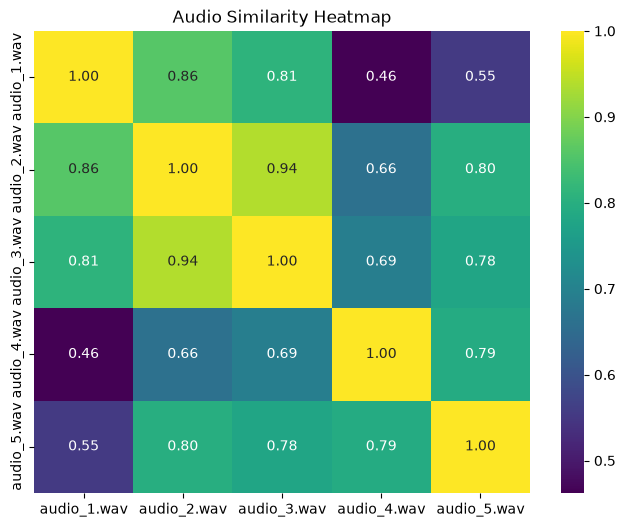

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    similarity_df,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title(
    "Audio Similarity Heatmap"
)

plt.show()

### Distance Matrix

In [10]:
distance_matrix = cdist(
    embeddings,
    embeddings,
    metric="euclidean"
)

distance_df = pd.DataFrame(
    distance_matrix,
    index=labels,
    columns=labels
)

distance_df

,audio_1.wav,audio_2.wav,audio_3.wav,audio_4.wav,audio_5.wav
audio_1.wav,0.000000,5.206588,5.423722,7.684710,7.267019
audio_2.wav,5.206588,0.000000,1.764703,3.645821,2.842731
audio_3.wav,5.423722,1.764703,0.000000,3.719771,3.198986
audio_4.wav,7.684710,3.645821,3.719771,0.000000,2.547534
audio_5.wav,7.267019,2.842731,3.198986,2.547534,0.000000


### Distance Heatmap

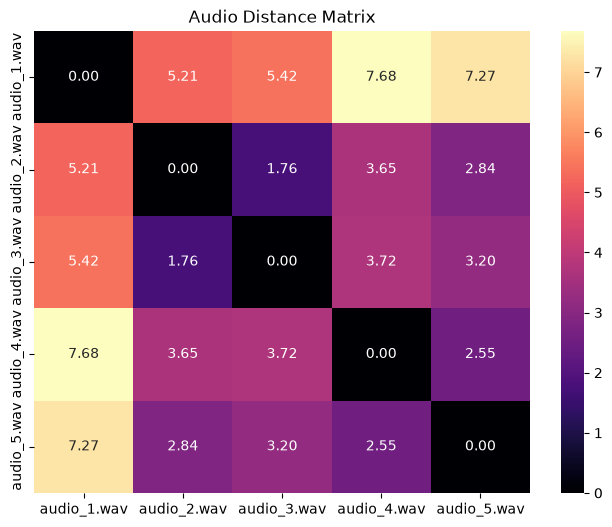

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    distance_df,
    annot=True,
    cmap="magma",
    fmt=".2f"
)

plt.title(
    "Audio Distance Matrix"
)

plt.show()

### PCA Visualization

In [12]:
pca = PCA(
    n_components=2
)

embeddings_2d = pca.fit_transform(
    embeddings
)

### Plot Embedding Space

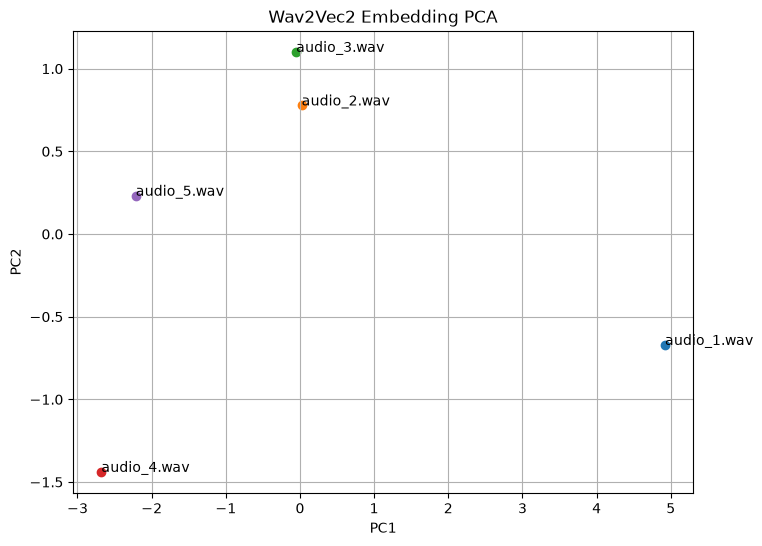

In [13]:
plt.figure(figsize=(8,6))

for i,label in enumerate(labels):

    plt.scatter(
        embeddings_2d[i,0],
        embeddings_2d[i,1]
    )

    plt.annotate(
        label,
        (
            embeddings_2d[i,0],
            embeddings_2d[i,1]
        )
    )

plt.title(
    "Wav2Vec2 Embedding PCA"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid()

plt.show()

### Find Most Similar Pair

In [14]:
sim = similarity_matrix.copy()

np.fill_diagonal(
    sim,
    -1
)

idx = np.unravel_index(
    np.argmax(sim),
    sim.shape
)

print(
    "Most similar pair:"
)

print(
    labels[idx[0]],
    "<->",
    labels[idx[1]]
)

print(
    "Similarity:",
    sim[idx]
)

Most similar pair:
audio_2.wav <-> audio_3.wav
Similarity: 0.9384588


### Summary Table

In [16]:
summary = pd.DataFrame(
    {
        "Audio File": labels,
        "Embedding Dimension": [
            embeddings.shape[1]
        ] * len(labels)
    }
)

summary

,Audio File,Embedding Dimension
0,audio_1.wav,768
1,audio_2.wav,768
2,audio_3.wav,768
3,audio_4.wav,768
4,audio_5.wav,768
